# CenterFusion Training on nuScenes-mini (Kaggle)
**Paper:** *CenterFusion: Center-based Radar and Camera Fusion for 3D Object Detection* — Nabati & Qi, WACV 2021  
**Repo:** https://github.com/mrnabati/CenterFusion

This notebook trains CenterFusion end-to-end on the **nuScenes-mini** dataset on Kaggle.  
All required utilities from the repo are **embedded directly** in notebook cells so nothing external needs to be imported from the cloned repo at import-time.

### Prerequisites (Kaggle settings)
- **Accelerator:** GPU (T4 or P100)
- **Internet:** ON (for the initial clone)  
- **Dataset attached:** 

### Notebook Structure
1. Environment Setup
2. Repository Clone & Data Linking
3. Dependency Installation *(restart kernel after this cell)*
4. Data Conversion to COCO Format
5. Dataset Analysis
6. Augmentation Verification
7. Training
8. Evaluation & Results


## 1  Environment Setup — Clone & Link Data

In [1]:
# import os, subprocess, sys

# REPO_DIR   = "/kaggle/working/CenterFusion"
# DATA_ROOT  = "/kaggle/input/nuscenes-mini"          # adjust if your dataset slug differs
# NUSCENES_VERSION = "v1.0-mini"

# # ── Clone (skip if already present) ──────────────────────────────────────────
# if not os.path.isdir(REPO_DIR):
#     subprocess.run(["git", "clone", "https://github.com/mrnabati/CenterFusion.git", REPO_DIR],
#                    check=True)
#     print("Cloned CenterFusion.")
# else:
#     print("Repo already present, skipping clone.")

# # ── Symlink the dataset so the repo's expected path works ────────────────────
# nuscenes_link = os.path.join(REPO_DIR, "data", "nuscenes")
# os.makedirs(os.path.dirname(nuscenes_link), exist_ok=True)

# if not os.path.exists(nuscenes_link):
#     # Try common Kaggle dataset mount points
#     for candidate in [DATA_ROOT,
#                       "/kaggle/input/datasets/aadimator/nuscenes-mini",
#                       "/kaggle/input/nuscenes-mini/nuscenes-mini"]:
#         if os.path.isdir(candidate):
#             os.symlink(candidate, nuscenes_link)
#             print(f"Symlinked {candidate} → {nuscenes_link}")
#             break
#     else:
#         raise FileNotFoundError(
#             "Cannot find nuScenes-mini. Check the dataset slug in Kaggle → Add Data.")
# else:
#     print(f"Symlink already exists: {nuscenes_link}")

# print("Directory listing of data/nuscenes:")
# !ls -lh {nuscenes_link}


In [2]:
# Please note that the successing comments are written by Me and not AI.. So if you have any concerns, please tell me directly
!git clone https://github.com/mrnabati/CenterFusion.git # Clone the repo.
# cwd into the repo folder
%cd CenterFusion

# Create a symlink (short for symbolic link) (shortcut) to the dataset
!mkdir -p data/nuscenes
!ln -s /kaggle/input/datasets/aadimator/nuscenes-mini/* data/nuscenes

fatal: destination path 'CenterFusion' already exists and is not an empty directory.
/kaggle/working/CenterFusion
ln: failed to create symbolic link 'data/nuscenes/maps': File exists
ln: failed to create symbolic link 'data/nuscenes/samples': File exists
ln: failed to create symbolic link 'data/nuscenes/sweeps': File exists
ln: failed to create symbolic link 'data/nuscenes/v1.0-mini': File exists


## 2  Install Dependencies
> ⚠️ **Restart the kernel after this cell completes.**

In [3]:
# Pin versions that are compatible with the 6-year-old repo
!pip install -q     nuscenes-devkit     "numpy<2.0"     "scipy<1.13"     "pandas<2.2"     pyquaternion     matplotlib     Pillow     opencv-python-headless

print("✅ Dependencies installed. RESTART THE KERNEL NOW before continuing.")


✅ Dependencies installed. RESTART THE KERNEL NOW before continuing.


## 3  Verify Environment *(run after kernel restart)*

In [4]:
import sys, os
import numpy as np
import torch

print(f"Python  : {sys.version.split()[0]}")
print(f"NumPy   : {np.__version__}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}  ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'})")

REPO_DIR = "/kaggle/working/CenterFusion"
sys.path.insert(0, os.path.join(REPO_DIR, "src", "lib"))
sys.path.insert(0, os.path.join(REPO_DIR, "src"))
print(f"Repo    : {REPO_DIR}")


Python  : 3.12.12
NumPy   : 1.26.4
PyTorch : 2.10.0+cu128
CUDA    : True  (Tesla T4)
Repo    : /kaggle/working/CenterFusion


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.892 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


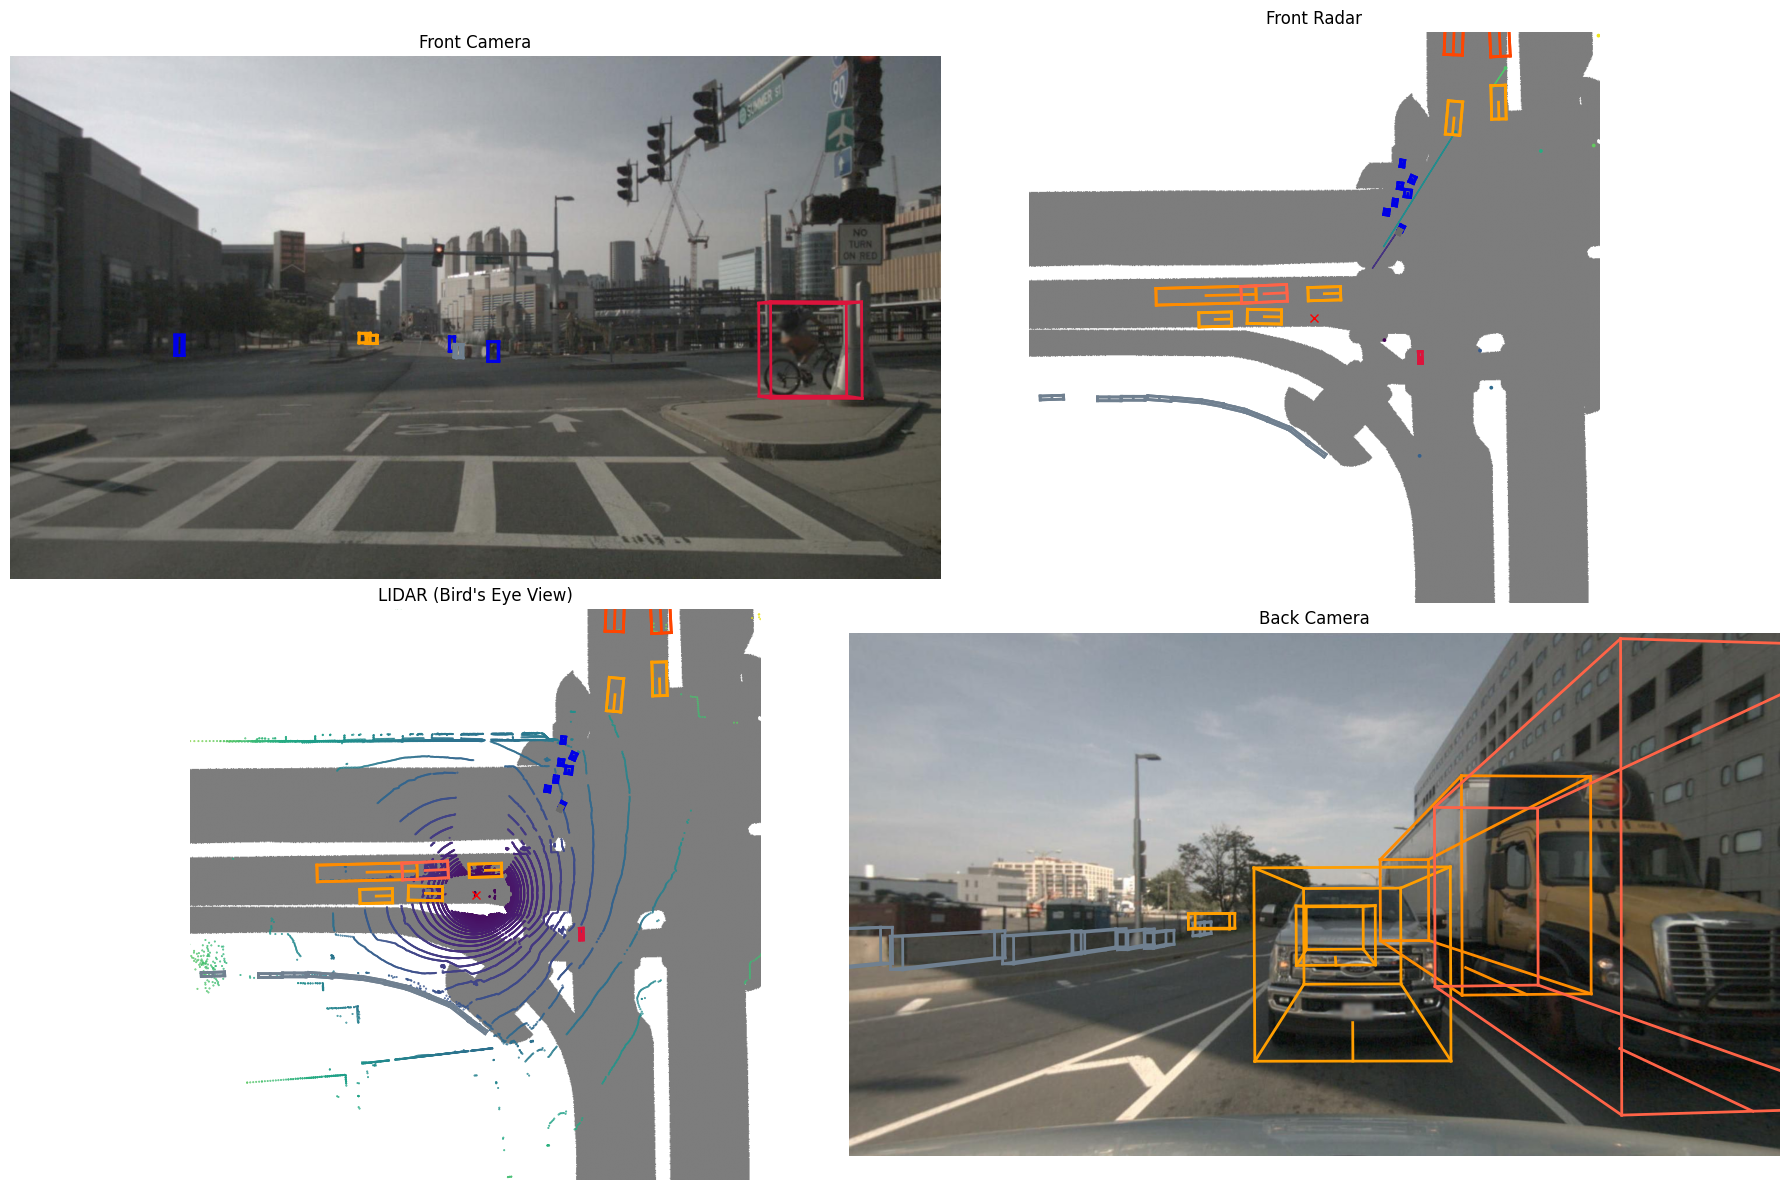

In [5]:
from nuscenes.nuscenes import NuScenes

# 2. Initialize the NuScenes object pointing to Kaggle's read-only input directory
nusc = NuScenes(version='v1.0-mini', dataroot='/kaggle/input/datasets/aadimator/nuscenes-mini', verbose=True)

# 3. Get the very first "Scene" (a 20-second continuous video clip)
my_scene = nusc.scene[2]

# 4. Get the token (ID) for the very first "Sample" (snapshot) in that scene
first_sample_token = my_scene['first_sample_token']

# 5. Fetch the actual sample data using the token
my_sample = nusc.get('sample', first_sample_token)

import matplotlib.pyplot as plt

# 1. Create the afigure and a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 2. Render Front Camera (Top-Left)
# Setting verbose=False prevents the SDK from 'finishing' the plot early
nusc.render_sample_data(my_sample['data']['CAM_FRONT'], ax=axes[0, 0], verbose=False)
axes[0, 0].set_title("Front Camera")

# 3. Render Front Radar (Top-Right)
nusc.render_sample_data(my_sample['data']['RADAR_FRONT'], ax=axes[0, 1], verbose=False)
axes[0, 1].set_title("Front Radar")

# 4. Render LIDAR Top-Down (Bottom-Left)
nusc.render_sample_data(my_sample['data']['LIDAR_TOP'], ax=axes[1, 0], verbose=False)
axes[1, 0].set_title("LIDAR (Bird's Eye View)")

# 5. Render Back Camera (Bottom-Right)
nusc.render_sample_data(my_sample['data']['CAM_BACK'], ax=axes[1, 1], verbose=False)
axes[1, 1].set_title("Back Camera")

# 6. Final display call
plt.tight_layout()
plt.show()

## 4  Convert nuScenes to COCO Format

In [6]:
!sudo chown -R $USER:$USER /kaggle/working/CenterFusion/
!chmod -R 777 /kaggle/working/CenterFusion/data

In [7]:
import os
os.makedirs('/kaggle/working/annotations', exist_ok=True)

In [8]:
%cd /kaggle/working/CenterFusion/src/tools
# Format the training data
!python convert_nuScenes.py --nusc_path data/nuscenes --nusc_version v1.0-mini --split mini_train

# Format the validation data
!python convert_nuScenes.py --nusc_path data/nuscenes --nusc_version v1.0-mini --split mini_val

/kaggle/working/CenterFusion/src/tools
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.447 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
scene_name scene-0103
scene_name scene-0916
reordering images
mini_val 486 images 4910 boxes
out_path ../../data/nuscenes/annotations_6sweeps/mini_val.json
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.416 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
scene_name scene-0061
scene_name scene-0553
scene_name scene-0655
scene_name scene-0757
scene_name scene-0796
scene_name scene-1077
scene_name scene-1094
scene

In [9]:
%cd /kaggle/working/CenterFusion
!ls -lh /kaggle/working/CenterFusion/data/nuscences/annotations/

/kaggle/working/CenterFusion
ls: cannot access '/kaggle/working/CenterFusion/data/annotations/': No such file or directory


In [10]:
import os, subprocess

REPO_DIR = "/kaggle/working/CenterFusion"
TOOLS_DIR = os.path.join(REPO_DIR, "src", "tools")
import json
from collections import Counter

def analyze_coco_json(file_path):
    print(f"Loading {file_path}...")
    with open(file_path, 'r') as f:
        data = json.load(f)
        
    # 1. Get total images
    num_images = len(data.get('images', []))
    print(f"Total Images: {num_images}")
    
    # 2. Map category IDs to readable names
    cat_mapping = {cat['id']: cat['name'] for cat in data.get('categories', [])}
    
    # 3. Count every 3D bounding box by its class
    category_counts = Counter()
    for ann in data.get('annotations', []):
        cat_name = cat_mapping.get(ann['category_id'], 'Unknown')
        category_counts[cat_name] += 1
        
    print(f"Total Annotations (3D Bounding Boxes): {len(data.get('annotations', []))}")
    print("\n--- Breakdown by Class ---")
    
    # Print sorted by highest count
    for cat_name, count in category_counts.most_common():
        print(f"{cat_name}: {count}")
    print("="*40 + "\n")

# Run it on both files
# Note: If your previous 'ls' command showed these files directly in the CenterFusion folder, 
# change the base_path to "/kaggle/working/CenterFusion/"
base_path = "/kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/"

try:
    analyze_coco_json(base_path + "mini_train.json")
    analyze_coco_json(base_path + "mini_val.json")
except FileNotFoundError as e:
    print(f"File not found. Check if the path is correct: {e}")

Loading /kaggle/working/CenterFusion/data/annotations/mini_train.json...
File not found. Check if the path is correct: [Errno 2] No such file or directory: '/kaggle/working/CenterFusion/data/annotations/mini_train.json'


## 5  Dataset Analysis

In [13]:
import json, os
from collections import Counter

def analyze_coco_json(file_path):
    """Analyze a COCO-format annotation file and print per-class counts."""
    print(f"Loading {os.path.basename(file_path)} ...")
    with open(file_path, "r") as f:
        data = json.load(f)

    num_images = len(data.get("images", []))
    print(f"  Images      : {num_images}")

    cat_mapping = {cat["id"]: cat["name"] for cat in data.get("categories", [])}
    category_counts = Counter()
    for ann in data.get("annotations", []):
        cat_name = cat_mapping.get(ann["category_id"], "Unknown")
        category_counts[cat_name] += 1

    total_anns = len(data.get("annotations", []))
    print(f"  Annotations : {total_anns}  (3-D bounding boxes)")
    print("  Class breakdown:")
    for name, cnt in category_counts.most_common():
        bar = "█" * (cnt // 10)
        print(f"    {name:<20} {cnt:>5}  {bar}")
    print()
    return data


REPO_DIR = "/kaggle/working/CenterFusion"
# Support both possible annotation folder names
base_path = "/kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/"


train_json = os.path.join(base_path, "mini_train.json")
val_json   = os.path.join(base_path, "mini_val.json")

train_data = analyze_coco_json(train_json)
val_data   = analyze_coco_json(val_json)


Loading mini_train.json ...
  Images      : 1938
  Annotations : 14694  (3-D bounding boxes)
  Class breakdown:
    car                   5607  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    pedestrian            3568  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

## 6  Quick Dataset Visualization (nuScenes SDK)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.617 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


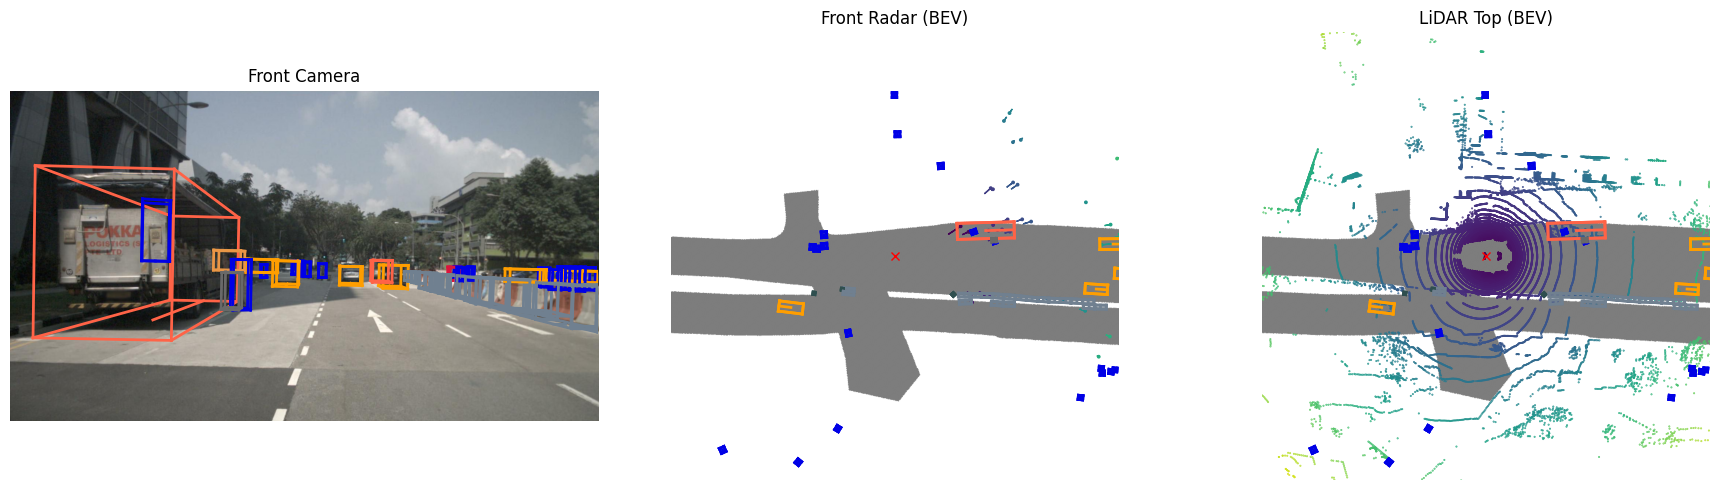

In [14]:
from nuscenes.nuscenes import NuScenes
import matplotlib.pyplot as plt

nusc = NuScenes(version="v1.0-mini",
                dataroot=os.path.realpath("/kaggle/working/CenterFusion/data/nuscenes"),
                verbose=True)

scene    = nusc.scene[0]
sample   = nusc.get("sample", scene["first_sample_token"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nusc.render_sample_data(sample["data"]["CAM_FRONT"],   ax=axes[0], verbose=False)
axes[0].set_title("Front Camera")
nusc.render_sample_data(sample["data"]["RADAR_FRONT"],  ax=axes[1], verbose=False)
axes[1].set_title("Front Radar (BEV)")
nusc.render_sample_data(sample["data"]["LIDAR_TOP"],    ax=axes[2], verbose=False)
axes[2].set_title("LiDAR Top (BEV)")
plt.tight_layout()
plt.show()


## 7  Embedded Training Utilities

The next two cells copy the **key components** from the CenterFusion repo directly
into the notebook so you can inspect and tweak them without touching repo files.


In [15]:
# ── 7a. Parse & display the training configuration ───────────────────────────
import sys, os
sys.path.insert(0, "/kaggle/working/CenterFusion/src/lib")
sys.path.insert(0, "/kaggle/working/CenterFusion/src")

from opts import opts as Opts

# Build the option object exactly as train.py does
opt = Opts().parse([
    "ddd",                       # task: 3-D detection
    "--dataset",    "nuscenes",
    "--exp_id",     "centerfusion_mini",
    "--batch_size", "4",         # safe for 16 GB GPU; bump to 8 if P100
    "--lr",         "5e-4",
    "--num_epochs", "30",        # paper trains 60 epochs; 30 gives a reasonable model
    "--lr_step",    "20",
    "--save_all",                  # keep every epoch checkpoint
    "--pointcloud",               # ← enables radar input
    "--radar_sweeps",   "6",
    "--val_intervals",  "5",      # run validation every 5 epochs
    "--flip",       "0.5",
    "--shift",      "0.1",
    "--gpus",       "0",
    "--num_workers", "4",
    "--input_w",    "800",
    "--input_h",    "448",
])

# Override data dir so the repo finds the annotations
opt.data_dir = "/kaggle/working/CenterFusion/data"
opt.dataset_version = "v1.0-mini"

print("Training configuration:")
print(f"  Task          : {opt.task}")
print(f"  Dataset       : {opt.dataset}  ({opt.dataset_version})")
print(f"  Batch size    : {opt.batch_size}")
print(f"  Epochs        : {opt.num_epochs}  (lr drops at epoch {opt.lr_step})")
print(f"  Learning rate : {opt.lr}")
print(f"  Radar sweeps  : {opt.radar_sweeps}")
print(f"  Input size    : {opt.input_w} × {opt.input_h}")
print(f"  Output dir    : {opt.save_dir}")


Fix size testing.
training chunk_sizes: [4]
Training configuration:
  Task          : ddd
  Dataset       : nuscenes  (v1.0-mini)
  Batch size    : 4
  Epochs        : 30  (lr drops at epoch [20])
  Learning rate : 0.0005
  Radar sweeps  : 6
  Input size    : 800 × 448
  Output dir    : /kaggle/working/CenterFusion/src/lib/../../exp/ddd/centerfusion_mini


In [16]:
# # ── 7b. Dataset loader sanity check (no training yet) ────────────────────────
# import numpy as np
# import torch

# from dataset.dataset_factory import dataset_factory

# Dataset = dataset_factory[opt.dataset]
# train_set = Dataset(opt, "mini_train")
# val_set   = Dataset(opt, "mini_val")

# print(f"Train samples : {len(train_set)}")
# print(f"Val   samples : {len(val_set)}")

# # Pull one batch to verify shapes
# batch = train_set[0]
# print("Sample batch keys:", list(batch.keys()))
# print("Image shape    :", batch["image"].shape)

# if "pc_2d" in batch:
#     print("Radar pc_2d    :", batch["pc_2d"].shape, "  (radar points projected to image)")
#     print("Radar pc_N     :", int(np.squeeze(batch.get("pc_N", 0))), " points")
# else:
#     print("⚠  No radar key (pc_2d) found — check --pointcloud flag")

# print("✅ Dataset loader OK")


Dataset version v1.0-mini
==> initializing mini_train data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=4.18s)
creating index...
index created!
Loaded mini_train 1938 samples
Dataset version v1.0-mini
==> initializing mini_val data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_val.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=1.23s)
creating index...
index created!
Loaded mini_val 486 samples
Train samples : 1938
Val   samples : 486


AttributeError: 'Namespace' object has no attribute 'heads'

## 8  Augmentation Verification (Flip + Radar)

Fix size testing.
training chunk_sizes: [32]
Dataset version v1.0-mini
==> initializing mini_train data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=4.18s)
creating index...
index created!
Loaded mini_train 1938 samples
Fix size testing.
training chunk_sizes: [32]
Dataset version v1.0-mini
==> initializing mini_train data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=4.12s)
creating index...
index created!
Loaded mini_train 1938 samples


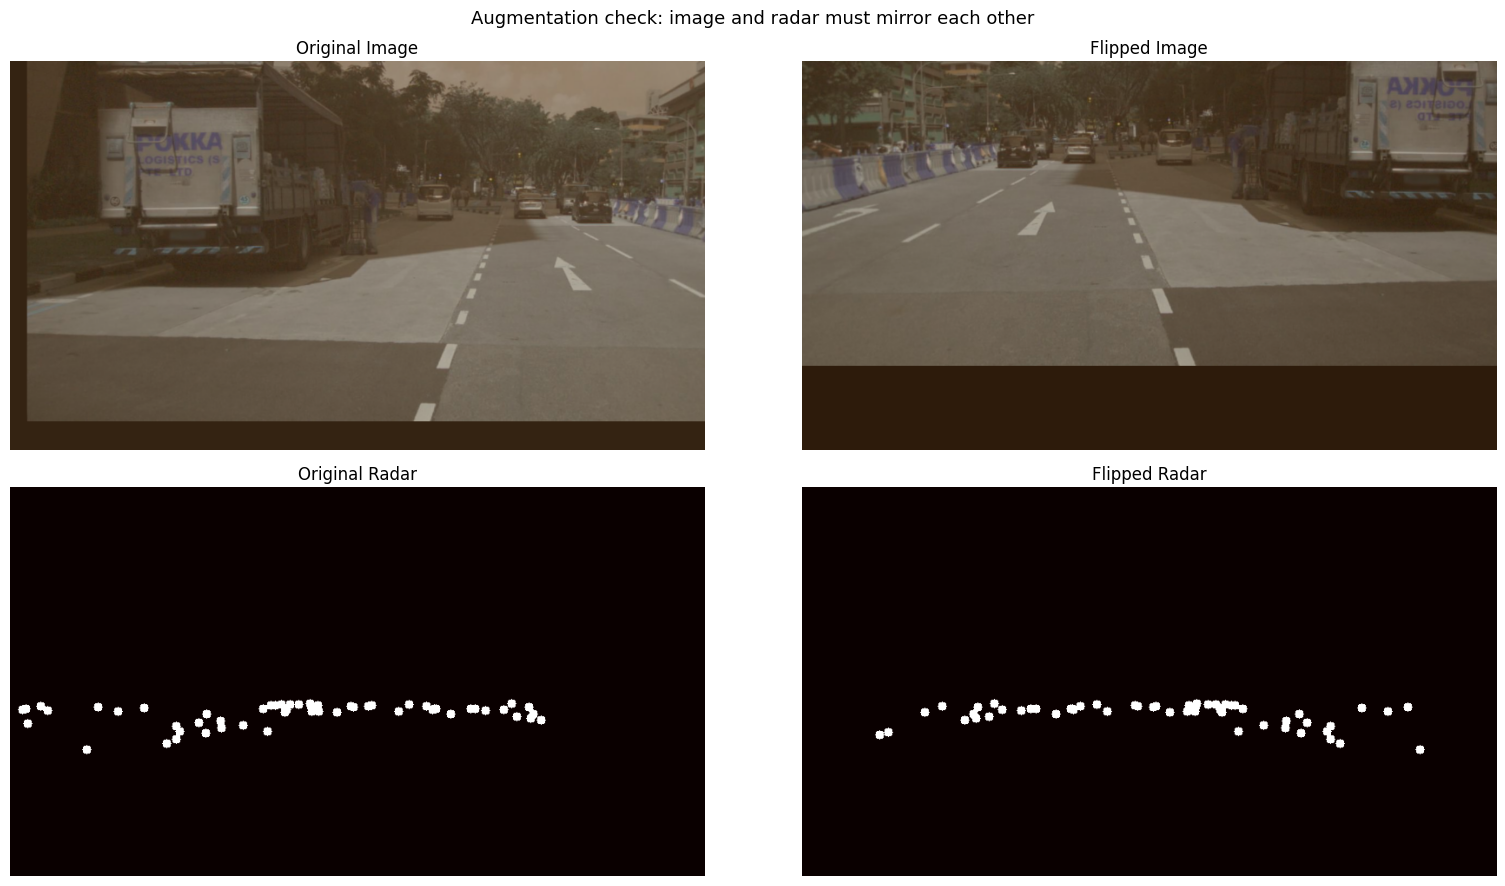

In [17]:
import cv2, numpy as np, matplotlib.pyplot as plt
from opts import opts as Opts
from dataset.dataset_factory import dataset_factory

def make_dataset(flip_prob):
    o = Opts().parse([
        "ddd", "--dataset", "nuscenes",
        "--pointcloud", "--radar_sweeps", "6",
        "--input_w", "800", "--input_h", "448",
    ])
    o.data_dir        = "/kaggle/working/CenterFusion/data"
    o.dataset_version = "v1.0-mini"
    o.heads = {"hm": 10, "reg": 2, "wh": 2, "dep": 1, "rot": 8, "dim": 3, "velocity": 3}
    o.num_classes = 10
    o.down_ratio  = 4
    o.output_w    = o.input_w // o.down_ratio
    o.output_h    = o.input_h // o.down_ratio
    o.flip  = flip_prob
    o.scale = 0.0
    o.shift = 0.0
    return dataset_factory[o.dataset](o, "mini_train")

ds_orig = make_dataset(0.0)
ds_flip = make_dataset(1.0)

MEAN = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
STD  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

def get_rgb(batch):
    t = batch["image"]
    if hasattr(t, "numpy"): t = t.numpy()
    return ((t[:3] * STD + MEAN).transpose(1,2,0) * 255).clip(0,255).astype(np.uint8)

def get_radar(batch):
    canvas = np.zeros((batch["image"].shape[1], batch["image"].shape[2]), np.uint8)
    if "pc_2d" not in batch:
        return canvas
    pc = batch["pc_2d"]
    if hasattr(pc, "numpy"): pc = pc.numpy()
    N = int(np.squeeze(batch.get("pc_N", 0)))
    H, W = canvas.shape
    xs = pc[0, :N] * (W / 1600.0)
    ys = pc[1, :N] * (H / 900.0)
    for x, y in zip(xs, ys):
        ix, iy = int(x), int(y)
        if 0 <= ix < W and 0 <= iy < H:
            cv2.circle(canvas, (ix, iy), 5, 255, -1)
    return canvas

b0, b1 = ds_orig[0], ds_flip[0]
fig, ax = plt.subplots(2, 2, figsize=(16, 9))
ax[0,0].imshow(get_rgb(b0));    ax[0,0].set_title("Original Image");         ax[0,0].axis("off")
ax[0,1].imshow(get_rgb(b1));    ax[0,1].set_title("Flipped Image");          ax[0,1].axis("off")
ax[1,0].imshow(get_radar(b0), cmap="hot"); ax[1,0].set_title("Original Radar"); ax[1,0].axis("off")
ax[1,1].imshow(get_radar(b1), cmap="hot"); ax[1,1].set_title("Flipped Radar");  ax[1,1].axis("off")
plt.suptitle("Augmentation check: image and radar must mirror each other", fontsize=13)
plt.tight_layout(); plt.show()


## 9  Training

The cell below launches training via the repo's .  
All flags are explained inline. The model checkpoints land in  
.

**Estimated time on Kaggle T4:** ~35–45 min for 30 epochs.  
Set  to match the paper's full schedule (~70 min).


In [26]:
!pip install torchvision==0.17.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 84.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 71.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 32.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━

In [27]:
import subprocess, sys, os
import torchvision
REPO_DIR = "/kaggle/working/CenterFusion"
TRAIN_SCRIPT = os.path.join(REPO_DIR, "src", "main.py")

cmd = [
    sys.executable, TRAIN_SCRIPT,
    "ddd",                          # task: 3-D detection (uses CenterNet3D head)
    "--dataset",    "nuscenes",      # dataset name (maps to NuScenesDataset class)
    "--exp_id",     "centerfusion_mini",
    "--data_dir",   os.path.join(REPO_DIR, "data"),
    "--dataset_version", "v1.0-mini",
    "--batch_size", "4",            # 4 fits comfortably on a T4; use 8 on P100
    "--master_batch_size", "4",
    "--lr",         "5e-4",         # paper uses 5e-4
    "--num_epochs", "30",           # full paper: 60; 30 gives decent results
    "--lr_step",    "20",           # halve lr at epoch 20
    "--save_all",                    # save checkpoint every epoch
    "--pointcloud",                  # enable radar point cloud branch
    "--radar_sweeps",  "6",         # aggregate 6 radar sweeps (≈0.25 s)
    "--flip",       "0.5",          # random left-right flip (p=0.5)
    "--shift",      "0.1",          # random image shift (up to 10%)
    "--val_intervals",  "5",        # evaluate on val set every 5 epochs
    "--gpus",       "0",            # GPU index
    "--num_workers", "4",
    "--input_w",    "800",          # paper uses 800×448 (half of 1600×900)
    "--input_h",    "448",
    "--test_scales", "1",
    "--load_model", "",             # start from scratch; set to a .pth to fine-tune
]

print("Launching training ...")
print("Command:", " ".join(cmd))
print("=" * 70)

result = subprocess.run(cmd, cwd=REPO_DIR)
if result.returncode == 0:
    print("✅ Training complete!")
else:
    print(f"❌ Training exited with code {result.returncode}")


Launching training ...
Command: /usr/bin/python3 /kaggle/working/CenterFusion/src/main.py ddd --dataset nuscenes --exp_id centerfusion_mini --data_dir /kaggle/working/CenterFusion/data --dataset_version v1.0-mini --batch_size 4 --master_batch_size 4 --lr 5e-4 --num_epochs 30 --lr_step 20 --save_all --pointcloud --radar_sweeps 6 --flip 0.5 --shift 0.1 --val_intervals 5 --gpus 0 --num_workers 4 --input_w 800 --input_h 448 --test_scales 1 --load_model 


Traceback (most recent call last):
  File "/kaggle/working/CenterFusion/src/main.py", line 11, in <module>
    from model.model import create_model, load_model, save_model
  File "/kaggle/working/CenterFusion/src/lib/model/model.py", line 14, in <module>
    from .networks.generic_network import GenericNetwork
  File "/kaggle/working/CenterFusion/src/lib/model/networks/generic_network.py", line 9, in <module>
    from .backbones.mobilenet import MobileNetV2
  File "/kaggle/working/CenterFusion/src/lib/model/networks/backbones/mobilenet.py", line 14, in <module>
    from torchvision.models.utils import load_state_dict_from_url
ModuleNotFoundError: No module named 'torchvision.models.utils'


import DCN failed
Import DCN failed
❌ Training exited with code 1


## 10  Monitor Checkpoints

In [ ]:
import os, glob

EXP_DIR = "/kaggle/working/CenterFusion/exp/ddd/centerfusion_mini"

ckpts = sorted(glob.glob(os.path.join(EXP_DIR, "model_*.pth")))
if ckpts:
    print(f"Found {len(ckpts)} checkpoint(s):")
    for c in ckpts:
        sz = os.path.getsize(c) / 1e6
        print(f"  {os.path.basename(c)}  ({sz:.1f} MB)")
else:
    print("No checkpoints found yet — training may still be running.")

# Show latest log excerpt
log_file = os.path.join(EXP_DIR, "log.txt")
if os.path.exists(log_file):
    with open(log_file) as f:
        lines = f.readlines()
    print("Last 30 log lines:")
    print("".join(lines[-30:]))


## 11  Evaluation on Validation Split

Run the official nuScenes evaluation protocol.


In [ ]:
import subprocess, sys, os, glob

REPO_DIR  = "/kaggle/working/CenterFusion"
EXP_DIR   = os.path.join(REPO_DIR, "exp", "ddd", "centerfusion_mini")

# Pick the best (last) checkpoint
ckpts = sorted(glob.glob(os.path.join(EXP_DIR, "model_*.pth")))
if not ckpts:
    raise FileNotFoundError("No checkpoints found. Run training first.")

best_ckpt = ckpts[-1]   # use last epoch; swap for model_best.pth if available
print(f"Evaluating checkpoint: {os.path.basename(best_ckpt)}")

cmd = [
    sys.executable, os.path.join(REPO_DIR, "src", "main.py"),
    "ddd",
    "--dataset",    "nuscenes",
    "--exp_id",     "centerfusion_mini_eval",
    "--data_dir",   os.path.join(REPO_DIR, "data"),
    "--dataset_version", "v1.0-mini",
    "--load_model", best_ckpt,
    "--test",                        # evaluation mode (no gradient)
    "--pointcloud",
    "--radar_sweeps",  "6",
    "--flip_test",                   # paper uses flip-test augmentation at inference
    "--gpus",       "0",
    "--num_workers", "4",
    "--input_w",    "800",
    "--input_h",    "448",
    "--test_scales", "1",
]

result = subprocess.run(cmd, cwd=REPO_DIR)
if result.returncode == 0:
    print("✅ Evaluation complete!")
else:
    print(f"❌ Evaluation exited with code {result.returncode}")


## 12  Parse & Display nuScenes Metrics

In [ ]:
import json, os, glob

EXP_DIRS = sorted(glob.glob("/kaggle/working/CenterFusion/exp/ddd/centerfusion_mini*"))

metric_files = []
for d in EXP_DIRS:
    for f in glob.glob(os.path.join(d, "**", "metrics_summary.json"), recursive=True):
        metric_files.append(f)

if not metric_files:
    print("No metrics_summary.json found yet.")
else:
    for mf in metric_files:
        print(f"{'='*60}")
        print(f"Results from: {mf}")
        with open(mf) as f:
            m = json.load(f)

        nds = m.get("nd_score",  m.get("NDS",  "N/A"))
        mAP = m.get("mean_ap",   m.get("mAP",  "N/A"))

        print(f"  NDS  (nuScenes Detection Score) : {float(nds):.4f}" if nds != "N/A" else "  NDS  : N/A")
        print(f"  mAP  (mean Average Precision)   : {float(mAP):.4f}" if mAP != "N/A" else "  mAP  : N/A")

        error_keys = ["mean_dist_aps", "tp_errors"]
        for ek in error_keys:
            if ek in m:
                print(f"
  {ek}:")
                for k, v in m[ek].items():
                    print(f"    {k:<20}: {v:.4f}")

        # Per-class mAP
        if "mean_dist_aps" in m:
            pass  # already printed
        elif "per_class_ap" in m:
            print("Per-class mAP:")
            for cls, ap in sorted(m["per_class_ap"].items(), key=lambda x: -x[1]):
                bar = "█" * int(ap * 40)
                print(f"    {cls:<20} {ap:.3f}  {bar}")


## 13  Save Best Checkpoint to Output

In [ ]:
import shutil, os, glob

EXP_DIR    = "/kaggle/working/CenterFusion/exp/ddd/centerfusion_mini"
OUTPUT_DIR = "/kaggle/working"

ckpts = sorted(glob.glob(os.path.join(EXP_DIR, "model_*.pth")))

if ckpts:
    best = ckpts[-1]
    dst  = os.path.join(OUTPUT_DIR, "centerfusion_mini_" + os.path.basename(best))
    shutil.copy2(best, dst)
    print(f"✅ Saved: {dst}  ({os.path.getsize(dst)/1e6:.1f} MB)")

    # Also copy the log
    log_src = os.path.join(EXP_DIR, "log.txt")
    if os.path.exists(log_src):
        shutil.copy2(log_src, os.path.join(OUTPUT_DIR, "training_log.txt"))
        print("✅ Saved: training_log.txt")
else:
    print("No checkpoints found — run training first.")
